In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [ ]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red', label='Real IBM Stock Price')
  plt.plot(predicted, color='green', label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-"*30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-"*30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted)
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-"*30)



In [ ]:
#wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()



,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [ ]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values


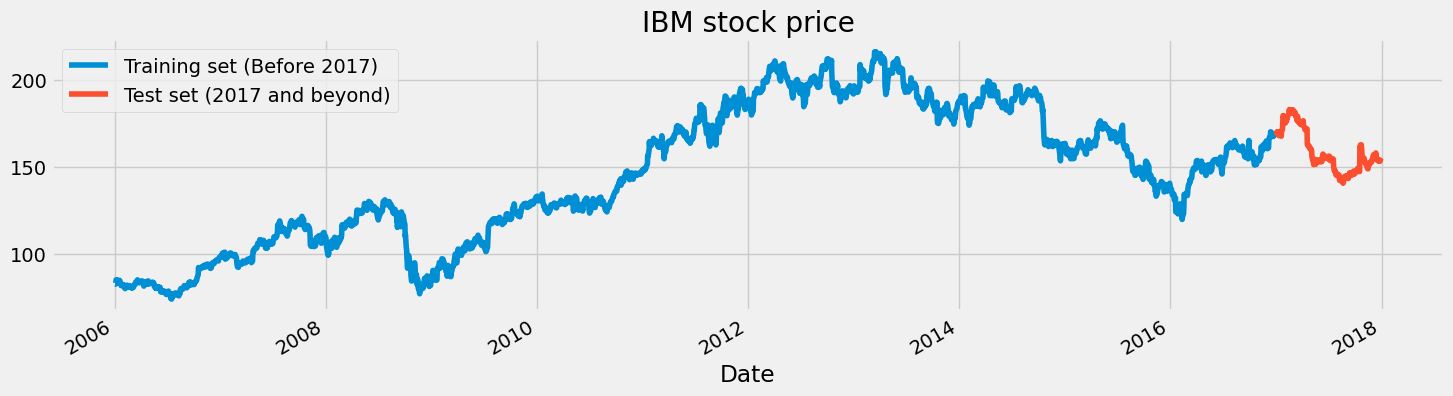

In [ ]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [ ]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
X_train =[]
Y_train =[]
for i in range(60,2769):
  X_train.append(training_set_scaled[i-60:i, 0])
  Y_train.append(training_set_scaled[i, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


## LSTM

In [ ]:
#Architektura sieć regresyjnej
regressor = Sequential()
#wejście
regressor.add(Input(shape=(X_train.shape[1],1)))
#pierwsza warstwa
regressor.add(LSTM(units=20, return_sequences=True))
regressor.add(Dropout(0.2))
#druga warstwa
regressor.add(LSTM(units=20, return_sequences=True))
regressor.add(Dropout(0.2))
#trzecia warstwa
regressor.add(LSTM(units=20, return_sequences=True))
regressor.add(Dropout(0.2))
#czwarta warstwa
regressor.add(LSTM(units=20))
regressor.add(Dropout(0.2))
#wyjście
regressor.add(Dense(units=1))

#ustawienie funkcji optymalizującej i funkcję strat
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# trenowanie sieć
regressor.fit(X_train,Y_train,epochs=50,batch_size=32)

#wersja treningu z mechanizmem Early Stopping
#early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
#regressor.fit(X_train,Y_train,epochs=100,batch_size=32, callback=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0281
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0102
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0094
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0082
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0075
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0065
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0064
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0045
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0043
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0042
Epoc

In [ ]:
#zestaw testowy
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set)-60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [ ]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


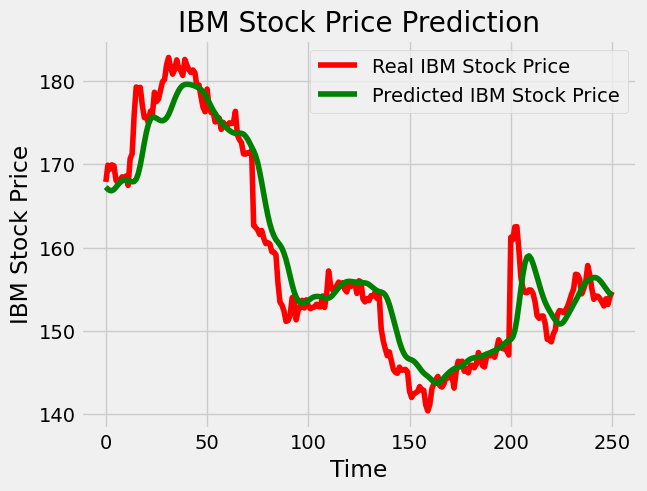

In [ ]:
#wizualizacja wyników
plot_predictions(test_set,predicted_stock_price)


In [ ]:
#ocena modelu
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.39.
------------------------------
Średni błąd bezwzględny: 2.35.
Średni błąd bezwzględny procentowy: 0.01%
------------------------------


## GRU

In [ ]:
regressorGRU = Sequential()
#wejście
regressorGRU.add(Input(shape=(X_train.shape[1],1)))

#pierwsza warstwa
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

#druga warstwa
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

#trzecia warstwa
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

#czwarta warstwa
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

#wyjście
regressorGRU.add(Dense(units=1))

#ustawienie funkcji optymalizującej i funkcję strat
regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

# trenowanie sieć bez Early Stopping
regressorGRU.fit(X_train,Y_train,epochs=50,batch_size=32)

#wersja treningu z mechanizmem Early Stopping
# early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
# regressorGRU.fit(X_train,Y_train,epochs=100,batch_size=32, callbacks=[early_stop])



Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0185
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0088
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0059
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0053
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0047
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0044
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0042
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0040
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0034
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0033
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0034
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0030
Epoc

In [ ]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


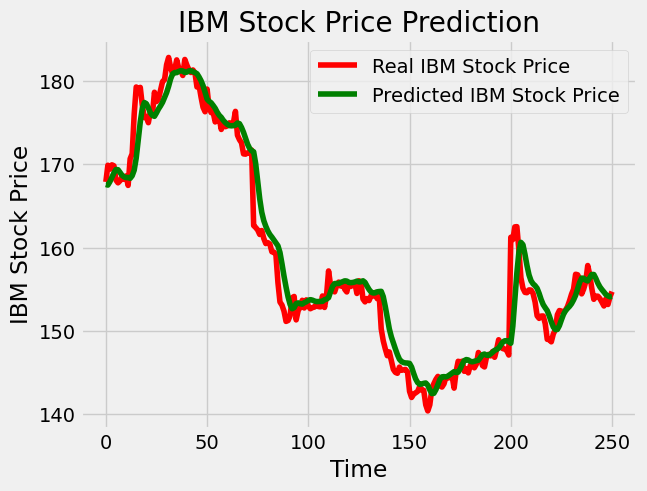

In [ ]:
#wizualizacja
plot_predictions(test_set,GRU_predicted_stock_price)


In [ ]:
#ocena modelu
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)
#

------------------------------
Błąd średniokwadratowy modelu 2.45.
------------------------------
Średni błąd bezwzględny: 1.65.
Średni błąd bezwzględny procentowy: 0.01%
------------------------------
